### 1. Import packages

In [1]:
import os, sys, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import (
    ZooAttack, HopSkipJump,
    FastGradientMethod, ProjectedGradientDescentPyTorch,
    DeepFool, CarliniL2Method, SaliencyMapMethod,
)

### 2. Model architecture & Scaled wrapper

In [3]:
class _ResidualBlock(nn.Module):
    def __init__(self, d_in, d_hid, p=0.25):
        super().__init__()
        self.lin1 = nn.Linear(d_in, d_hid)
        self.bn1  = nn.BatchNorm1d(d_hid)
        self.lin2 = nn.Linear(d_hid, d_in)
        self.ln2  = nn.LayerNorm(d_in)
        self.drop = nn.Dropout(p)
    def forward(self, x):
        h = self.drop(torch.relu(self.bn1(self.lin1(x))))
        return torch.relu(self.ln2(x + self.lin2(h)))

class _ResDNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        W = 512
        self.stem   = nn.Sequential(nn.Linear(in_dim, W), nn.BatchNorm1d(W), nn.ReLU(), nn.Dropout(0.30))
        self.block1 = _ResidualBlock(W, W // 2, p=0.30)
        self.block2 = _ResidualBlock(W, W // 2, p=0.25)
        self.block3 = _ResidualBlock(W, W // 2, p=0.20)
        self.head   = nn.Linear(W, n_classes)
    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(self.stem(x)))))

class _ScaledResDNN(nn.Module):
    """Wraps _ResDNN with embedded StandardScaler so ART operates in raw feature space."""
    def __init__(self, resdnn, mean, scale):
        super().__init__()
        self.resdnn = resdnn
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x = x.float()  # HSJA sends float64, model needs float32
        x_scaled = (x - self.mean_) / self.scale_
        return self.resdnn(x_scaled)

### 3. Load data and trained model

In [10]:
# Load test data
df_test = pd.read_csv('../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()
print(feature_names)
print(len(feature_names))
print(f'Test set: {X_test.shape}, Classes: {len(np.unique(y_test))}')

['flow IAT min', 'flow packet APDU length std', 'type_id_process_information_in_control_direction', 'type_id_system_information_in_control_direction', 'bw IAT min', 'flow packet APDU length var', 'bw packet APDU length max', 'flow packet APDU length max', 'bw packet APDU length std', 'flow IAT tot', 'total flow packets', 'bw packet APDU length var', 'cot=1', 'flow total IEC104_S_Message packets', 'flow packets APDU total length', 'cot=10', 'flow packet APDU length mean', 'flow duration', 'cot=3', 'flow active time min', 'fw packets APDU total length', 'bw packets APDU total length', 'flow IAT max', 'flow iec104 bytes/s', 'total fw packets', 'flow idle time max', 'fw IAT min', 'flow total IEC104_I_Message_SingleIOA packets', 'flow iec104 packts/s', 'bw packet APDU length mean', 'flow idle time mean', 'type_id_process_information_in_monitor_direction', 'fw iAT tot', 'flow IAT std', 'flow active time std', 'fw IAT mean', 'bw iec104 bytes/s', 'flow active time variance', 'bw iec104 packts/

In [11]:
# Load ResDNN checkpoint
DEVICE = 'cpu'  # change to 'cuda' if GPU available
ckpt = torch.load('../../training/models/framework_resdnn_TVAE.pth', map_location=DEVICE, weights_only=False)

resdnn_net = _ResDNN(
    in_dim=int(ckpt['in_dim']),
    n_classes=int(ckpt['n_classes']),
)
resdnn_net.load_state_dict(ckpt['state_dict'])
resdnn_net.eval()

scaled_model = _ScaledResDNN(resdnn_net, ckpt['scaler'].mean_, ckpt['scaler'].scale_).to(DEVICE)
scaled_model.eval()

num_classes = int(ckpt['n_classes'])
input_dim = int(ckpt['in_dim'])

print(f'ResDNN loaded: input_dim={input_dim}, classes={num_classes}')

ResDNN loaded: input_dim=66, classes=12


### 4. Create ART classifier

Original Accuracy: 68.89%
Original Precision: 68.52%
Original Recall: 68.89%
Original F1 Score: 0.6737


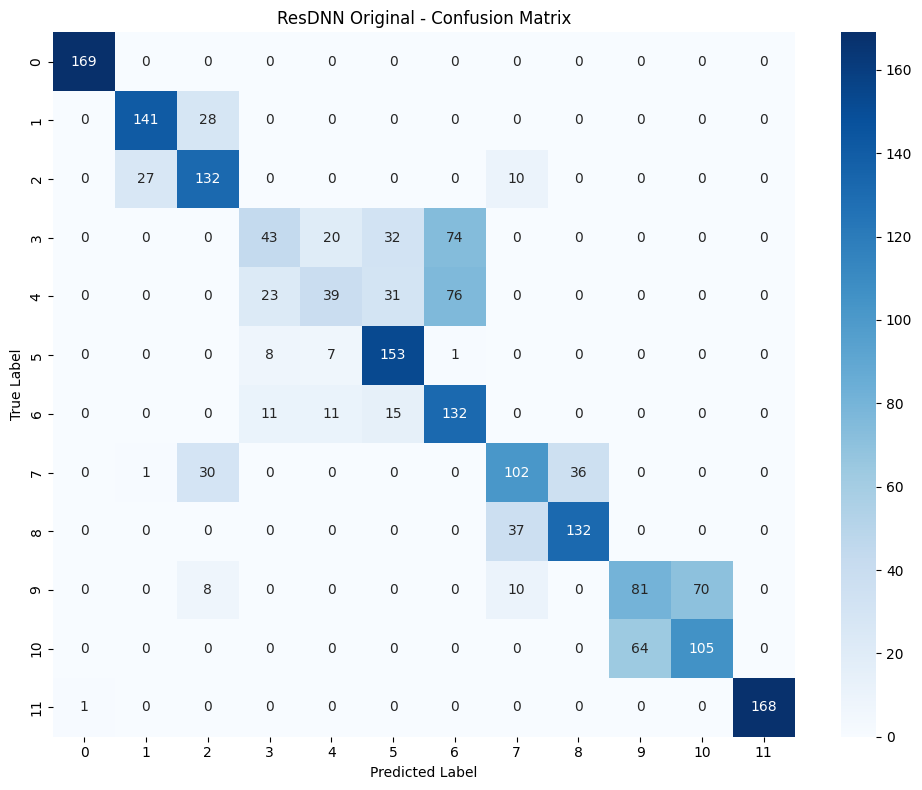

In [12]:
classifier = PyTorchClassifier(
    model=scaled_model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

predictions = classifier.predict(X_test)
original_preds = np.argmax(predictions, axis=1)

original_accuracy = accuracy_score(y_test, original_preds) * 100
original_f1 = f1_score(y_test, original_preds, average='weighted')
original_precision = precision_score(y_test, original_preds, average='weighted') * 100
original_recall = recall_score(y_test, original_preds, average='weighted') * 100

print(f'Original Accuracy: {original_accuracy:.2f}%')
print(f'Original Precision: {original_precision:.2f}%')
print(f'Original Recall: {original_recall:.2f}%')
print(f'Original F1 Score: {original_f1:.4f}')

cm = confusion_matrix(y_test, original_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('ResDNN Original - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [27]:
def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100

    print(f'--- {attack_name} ---')
    print(f'Accuracy on {attack_name} adversarial examples: {accuracy:.2f}%')
    print(f'Precision on {attack_name} adversarial examples: {precision:.2f}%')
    print(f'Recall on {attack_name} adversarial examples: {recall:.2f}%')
    print(f'F1 Score on {attack_name} adversarial examples: {f1:.4f}')

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'ResDNN {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

def save_adv_csv(adv_samples, y, feature_names, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame(adv_samples, columns=feature_names)
    df['Label'] = y
    df.to_csv(path, index=False)
    print(f'Saved: {path}')

### 5. Generate adversarial samples

DL models support all 7 attacks: FGSM, PGD, DeepFool, CW, JSMA (white-box) + ZOO, HSJA (black-box)

#### FGSM

Runtime: 0.21s
--- FGSM ---
Accuracy on FGSM adversarial examples: 24.31%
Precision on FGSM adversarial examples: 40.56%
Recall on FGSM adversarial examples: 24.31%
F1 Score on FGSM adversarial examples: 0.2177


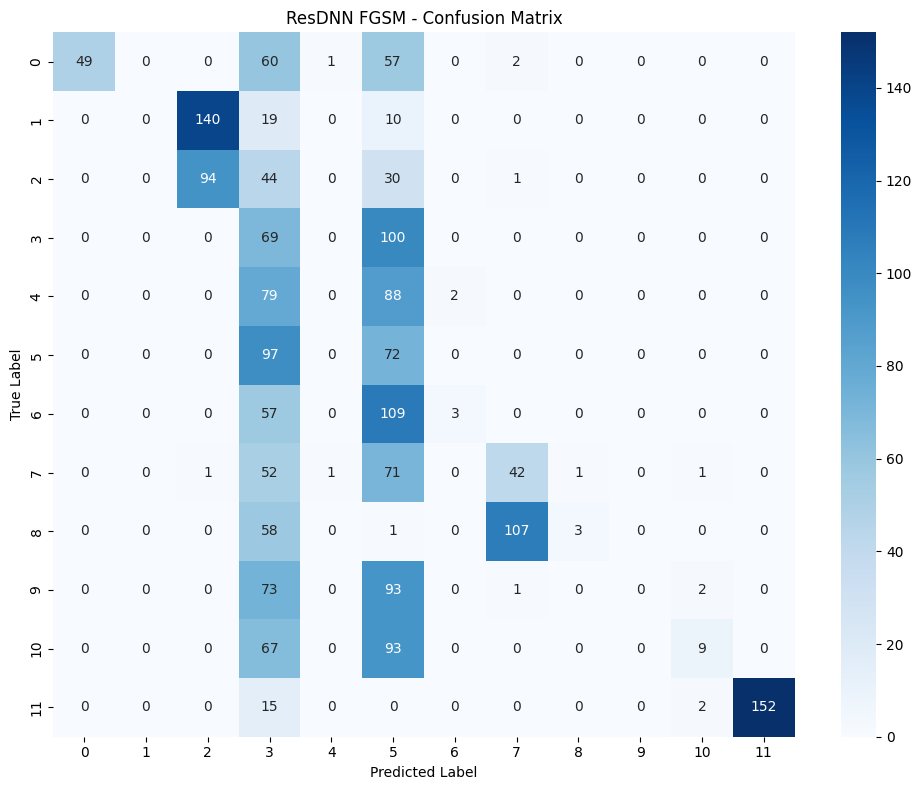

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_fgsm_adv.csv


In [12]:
attack = FastGradientMethod(
    estimator=classifier,
    eps=0.1,
    eps_step=0.01,
    batch_size=64,
    targeted=False,
)

start_time = time.time()
FGSM_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(FGSM_adv_samples)
evaluate_attack(y_test, predictions_adv, 'FGSM')
save_adv_csv(FGSM_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_fgsm_adv.csv')

#### PGD

Runtime: 16.40s
--- PGD ---
Accuracy on PGD adversarial examples: 20.76%
Precision on PGD adversarial examples: 30.34%
Recall on PGD adversarial examples: 20.76%
F1 Score on PGD adversarial examples: 0.2070


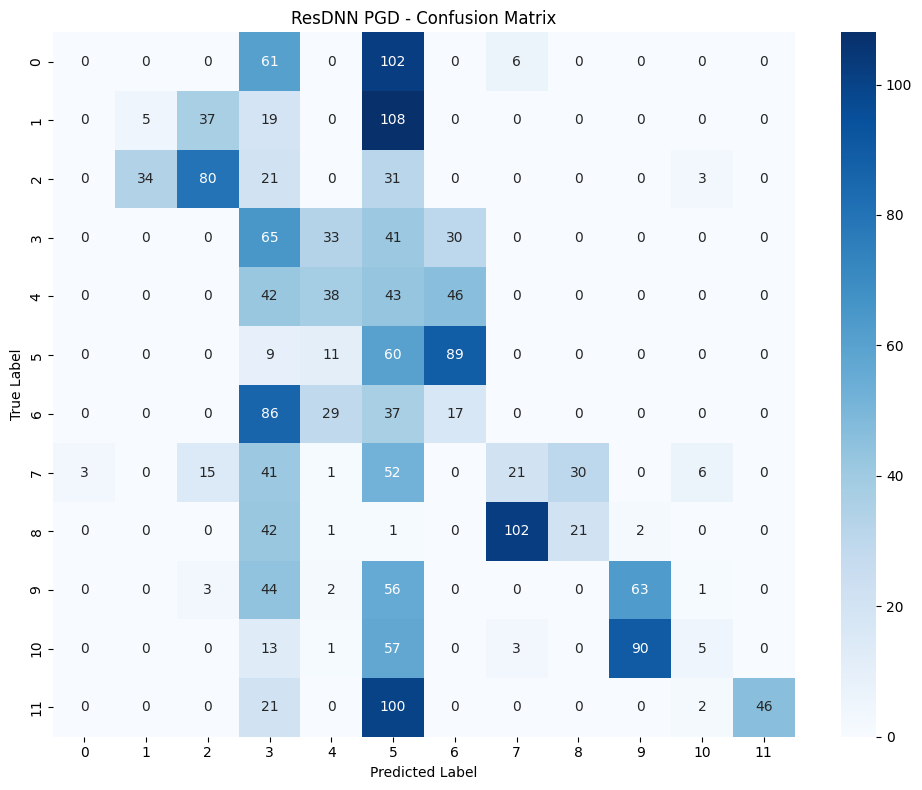

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_pgd_adv.csv


In [13]:
attack = ProjectedGradientDescentPyTorch(
    estimator=classifier,
    eps=0.2,
    eps_step=0.01,
    max_iter=200,
    batch_size=64,
    targeted=False,
    verbose=True,
)

start_time = time.time()
PGD_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(PGD_adv_samples)
evaluate_attack(y_test, predictions_adv, 'PGD')
save_adv_csv(PGD_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_pgd_adv.csv')

#### DeepFool

DeepFool: 100%|██████████| 32/32 [00:03<00:00, 10.17it/s]


Runtime: 3.19s
--- DeepFool ---
Accuracy on DeepFool adversarial examples: 3.60%
Precision on DeepFool adversarial examples: 4.86%
Recall on DeepFool adversarial examples: 3.60%
F1 Score on DeepFool adversarial examples: 0.0126


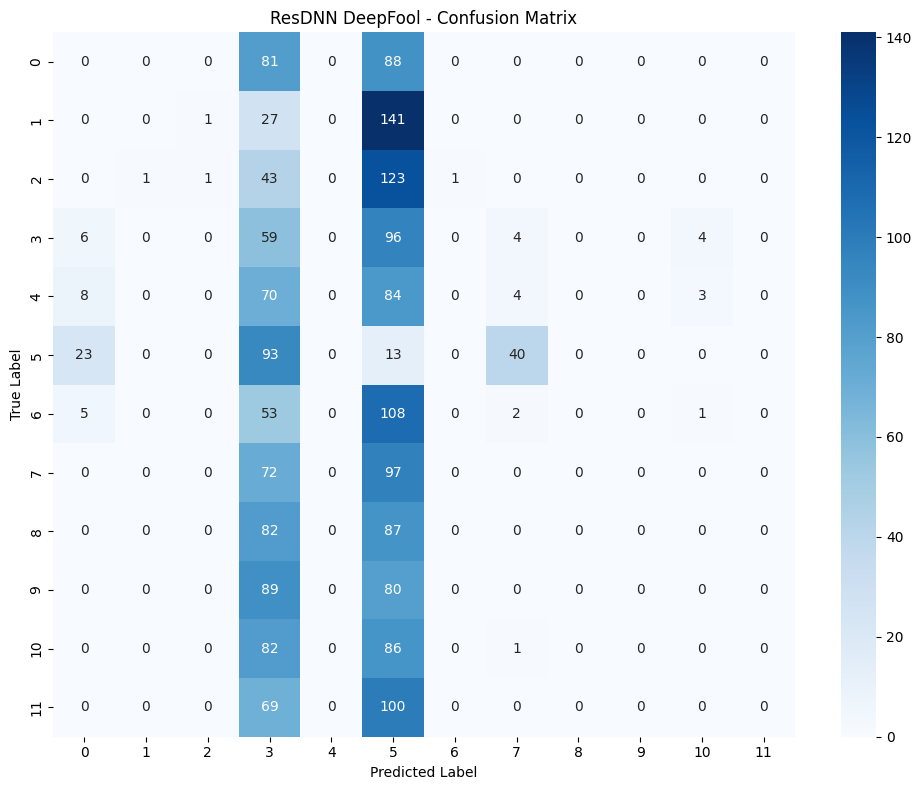

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_deepfool_adv.csv


In [14]:
attack = DeepFool(
    classifier=classifier,
    max_iter=100,
    batch_size=64,
    nb_grads=5,
    epsilon=1e-6,
)

start_time = time.time()
DeepFool_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(DeepFool_adv_samples)
evaluate_attack(y_test, predictions_adv, 'DeepFool')
save_adv_csv(DeepFool_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_deepfool_adv.csv')

#### C&W

Runtime: 6.47s
--- C&W ---
Accuracy on C&W adversarial examples: 41.81%
Precision on C&W adversarial examples: 45.45%
Recall on C&W adversarial examples: 41.81%
F1 Score on C&W adversarial examples: 0.3987


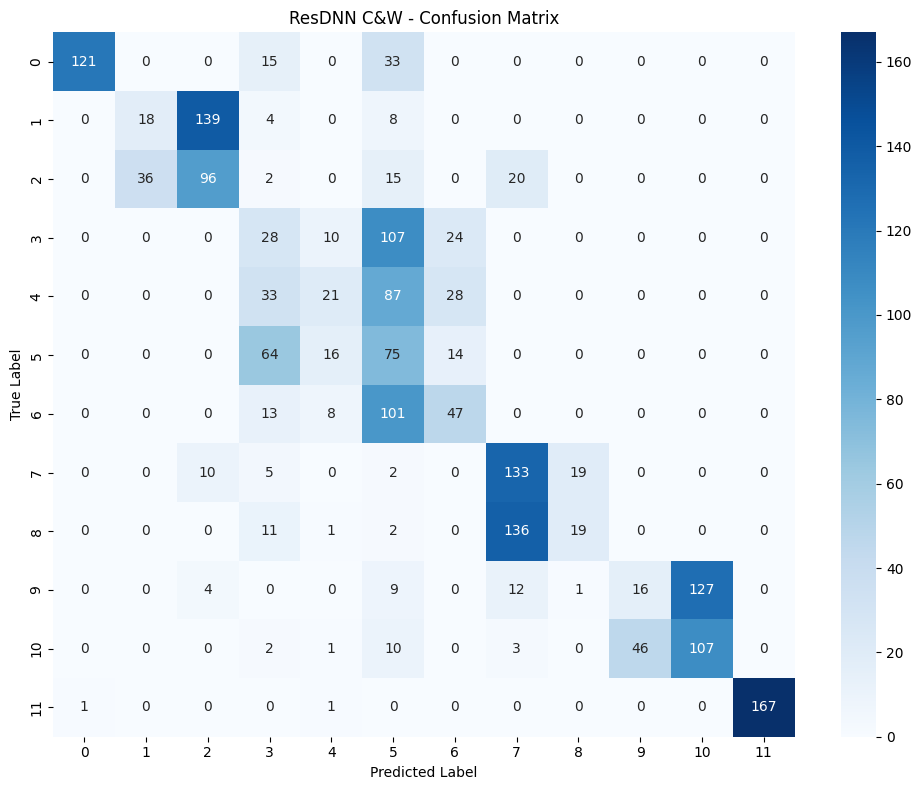

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_cw_adv.csv


In [15]:
attack = CarliniL2Method(
    classifier=classifier,
    confidence=0.0,
    learning_rate=0.01,
    binary_search_steps=3,
    max_iter=3,
    initial_const=0.01,
    max_halving=5,
    max_doubling=5,
    batch_size=64,
    verbose=False,
)

start_time = time.time()
CW_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(CW_adv_samples)
evaluate_attack(y_test, predictions_adv, 'C&W')
save_adv_csv(CW_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_cw_adv.csv')

#### JSMA

JSMA: 100%|██████████| 32/32 [15:27<00:00, 28.97s/it] 


Runtime: 927.13s
--- JSMA ---
Accuracy on JSMA adversarial examples: 5.92%
Precision on JSMA adversarial examples: 11.39%
Recall on JSMA adversarial examples: 5.92%
F1 Score on JSMA adversarial examples: 0.0627


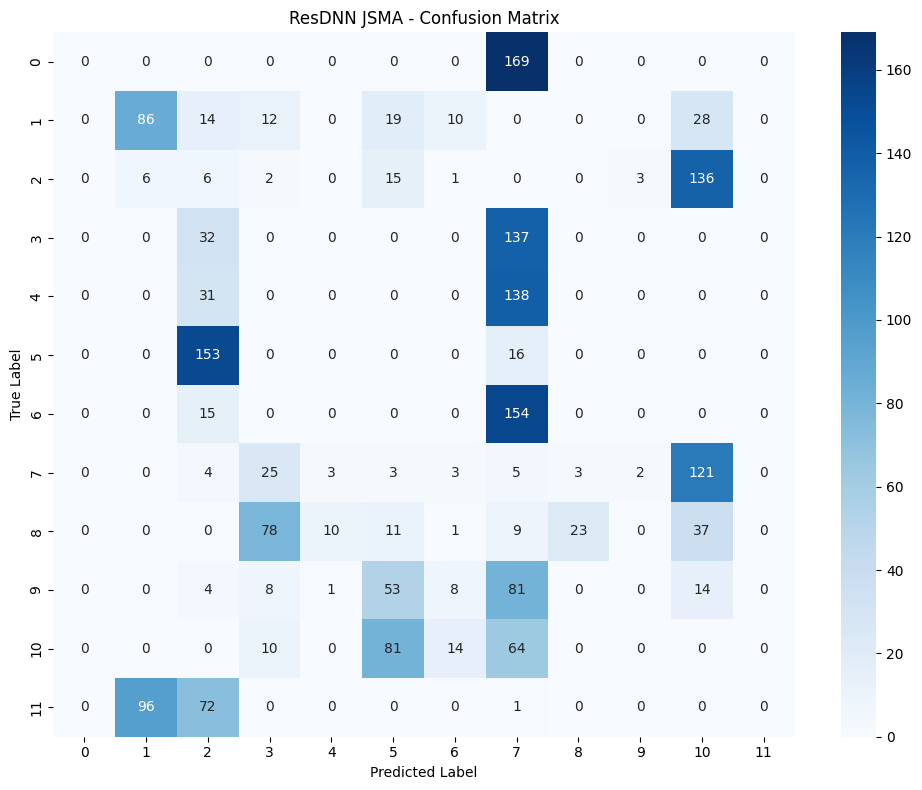

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_jsma_adv.csv


In [18]:
attack = SaliencyMapMethod(
    classifier=classifier,
    theta=0.02,
    gamma=0.1,
    batch_size=64,
    verbose=True,
)

start_time = time.time()
JSMA_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(JSMA_adv_samples)
evaluate_attack(y_test, predictions_adv, 'JSMA')
save_adv_csv(JSMA_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_jsma_adv.csv')

#### ZOO

ZOO: 100%|██████████| 2028/2028 [04:51<00:00,  6.95it/s]


Runtime: 293.08s
--- ZOO ---
Accuracy on ZOO adversarial examples: 17.41%
Precision on ZOO adversarial examples: 37.59%
Recall on ZOO adversarial examples: 17.41%
F1 Score on ZOO adversarial examples: 0.1674


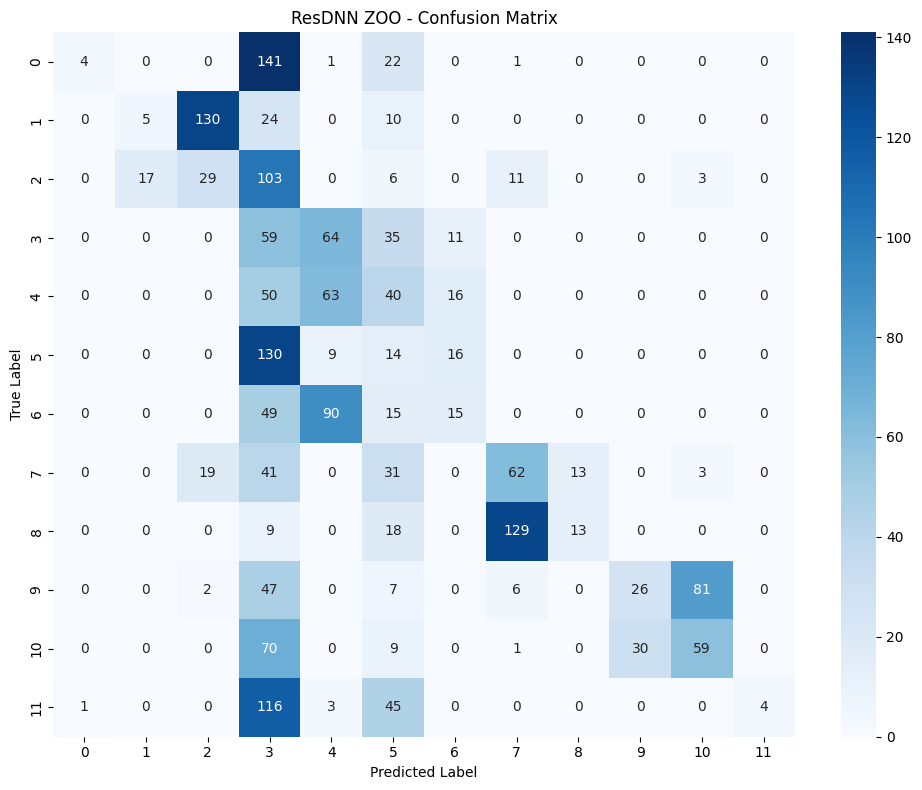

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_zoo_adv.csv


In [19]:
attack = ZooAttack(
    classifier=classifier,
    confidence=0.0,
    targeted=False,
    learning_rate=1e-1,
    max_iter=100,
    binary_search_steps=3,
    initial_const=1e-3,
    abort_early=True,
    use_resize=False,
    use_importance=False,
    nb_parallel=10,
    batch_size=1,
    variable_h=0.02,
)

start_time = time.time()
ZOO_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(ZOO_adv_samples)
evaluate_attack(y_test, predictions_adv, 'ZOO')
save_adv_csv(ZOO_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_zoo_adv.csv')

#### HSJA

HopSkipJump: 100%|██████████| 2028/2028 [00:58<00:00, 34.92it/s]


Runtime: 58.72s
--- HSJA ---
Accuracy on HSJA adversarial examples: 16.67%
Precision on HSJA adversarial examples: 12.80%
Recall on HSJA adversarial examples: 16.67%
F1 Score on HSJA adversarial examples: 0.1252


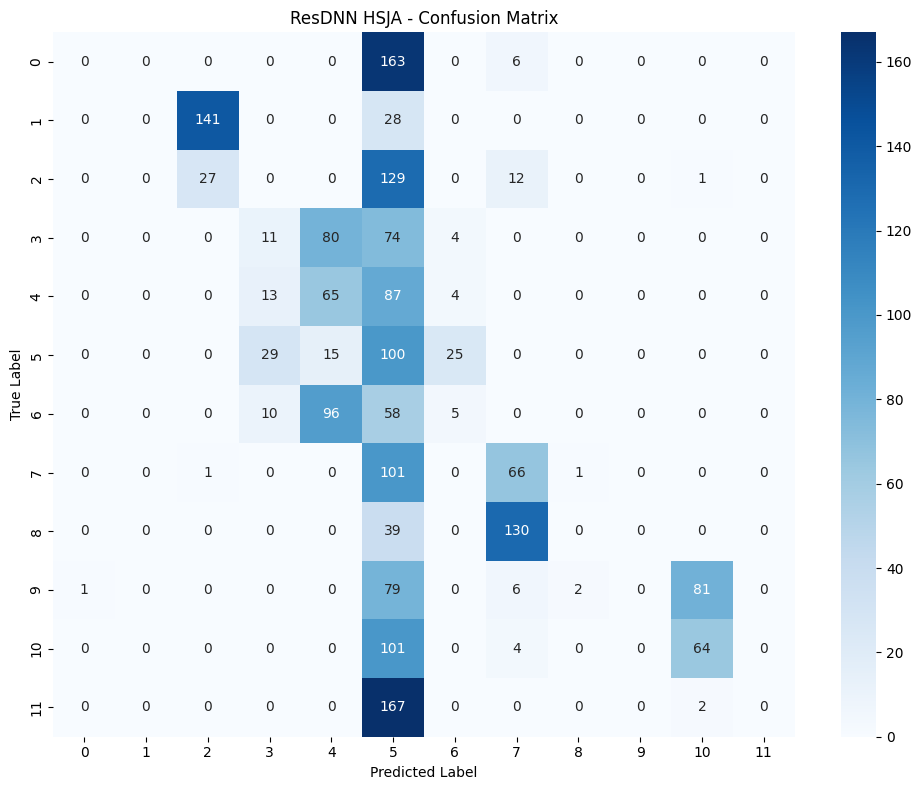

Saved: ../../adv_samples/adv_eval/resdnn/resdnn_hsja_adv.csv


In [28]:
attack = HopSkipJump(
    classifier=classifier,
    batch_size=12,
    targeted=False,
    norm=2,
    max_iter=5,
    max_eval=100,
    init_eval=10,
    init_size=10,
    verbose=True,
)

start_time = time.time()
HSJA_adv_samples = attack.generate(x=X_test)
print(f'Runtime: {time.time() - start_time:.2f}s')

predictions_adv = classifier.predict(HSJA_adv_samples)
evaluate_attack(y_test, predictions_adv, 'HSJA')
save_adv_csv(HSJA_adv_samples, y_test, feature_names, '../../adv_samples/adv_eval/resdnn/resdnn_hsja_adv.csv')

### 6. ASR (Attack Success Rate)

In [ ]:
# Original predictions
y_pred_org = original_preds
correct_indices = np.where(y_test == y_pred_org)[0]

attack_samples = {
    'FGSM': FGSM_adv_samples,
    'PGD': PGD_adv_samples,
    'DeepFool': DeepFool_adv_samples,
    'C&W': CW_adv_samples,
    'JSMA': JSMA_adv_samples,
    'ZOO': ZOO_adv_samples,
    'HSJA': HSJA_adv_samples,
}

print('=== ResDNN Attack Success Rate ===')
for name, adv in attack_samples.items():
    preds_adv = np.argmax(classifier.predict(adv), axis=1)
    asr = np.sum(y_pred_org[correct_indices] != preds_adv[correct_indices]) / len(correct_indices) * 100
    print(f'{name:>10s} ASR: {asr:.2f}%')

NameError: name 'original_preds' is not defined

In [5]:
# Original predictions
y_pred_org = original_preds
correct_indices = np.where(y_test == y_pred_org)[0]

attack_samples = {
    'FGSM': FGSM_adv_samples,
    'PGD': PGD_adv_samples,
    'DeepFool': DeepFool_adv_samples,
    'C&W': CW_adv_samples,
    'JSMA': JSMA_adv_samples,
    'ZOO': ZOO_adv_samples,
    'HSJA': HSJA_adv_samples,
}

print('=== ResDNN Attack Success Rate ===')
for name, adv in attack_samples.items():
    preds_adv = np.argmax(at_classifier['ResDNN'].predict(adv), axis=1)
    asr = np.sum(y_pred_org[correct_indices] != preds_adv[correct_indices]) / len(correct_indices) * 100
    print(f'{name:>10s} ASR: {asr:.2f}%')

NameError: name 'original_preds' is not defined